# Panel Features: Pairwise and Cross-Sectional Transforms

**Docker image**: `ml4t`

This notebook demonstrates panel-level temporal features: pairwise
relationships (cointegration, Kalman hedge ratios, O-U half-life) and
cross-sectional transforms (ranking, relative features, universe
aggregation).

Panel features matter because temporal features computed in isolation
(volatility, momentum, regime probabilities) gain signal when placed
in cross-sectional context — a 25% conditional volatility means
different things for a utility stock and a biotech.

**Learning Objectives**:
- Rank temporal features cross-sectionally for relative positioning
- Compute relative temporal features (vs. sector, vs. market)
- Test for cointegration using Engle-Granger and Johansen methods
- Estimate dynamic hedge ratios with Kalman filter
- Compute Ornstein-Uhlenbeck half-life for mean-reversion speed

**Book Reference**: Chapter 9, Section 9.6 (Cross-Sectional and Panel Features)

**Prerequisites**: `04_kalman_filter` for Kalman filter mechanics,
`11_hmm_regimes` for regime features used in universe aggregation.

In [1]:
"""Panel Features — pairwise and cross-sectional transforms for multi-asset temporal features."""

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# Kalman filter for dynamic hedge ratio
from filterpy.kalman import KalmanFilter
from IPython.display import display
from ml4t.engineer.features.cross_asset import (
    beta_to_market,
    co_integration_score,
    correlation_regime_indicator,
    rolling_correlation,
)
from sklearn.linear_model import LinearRegression

# Cointegration tests
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from data import load_etfs
from utils.paths import get_case_study_dir

.venv/lib/python3.14/site-packages/filterpy/common/helpers.py:367: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  P = \Sum {A[i] B[i].T} for i in 0..N
.venv/lib/python3.14/site-packages/ml4t/engineer/features/ml/__init__.py:9: UserWarning: Feature 'cyclical_encode': lookback=0 but has period/window parameter. Consider using lookback='period' or specifying the actual lookback.
  from ml4t.engineer.features.ml.cyclical_encode import *  # noqa: F403


In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all symbols
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

## Load Data

We use ETF pairs from the ETF Universe dataset to demonstrate pairs trading.
Classic cointegrated pairs include:
- **GLD/SLV** - Gold vs Silver (precious metals)
- **XLE/USO** - Energy sector vs Crude Oil
- **QQQ/SMH** - Nasdaq 100 vs Semiconductors (tech exposure)

In [3]:
# Load ETF universe data
etf_data = load_etfs()
if MAX_SYMBOLS > 0:
    symbols = etf_data["symbol"].unique().sort().to_list()[:MAX_SYMBOLS]
    etf_data = etf_data.filter(pl.col("symbol").is_in(symbols))

# Filter date range
etf_data = etf_data.filter(
    pl.col("timestamp").is_between(pl.lit(START_DATE).str.to_date(), pl.lit(END_DATE).str.to_date())
)

# Define pairs to test for cointegration
# Primary pair: XLE/USO (energy sector vs crude oil) with structural relationship
# Fallback pair: SPY/QQQ (available in all datasets for testing)
available_symbols = etf_data["symbol"].unique().to_list()
if "XLE" in available_symbols and "USO" in available_symbols:
    PAIR_Y = "XLE"  # Energy Sector ETF
    PAIR_X = "USO"  # Crude Oil ETF
else:
    # Fallback to symbols available in test fixtures
    print("Using fallback pair SPY/QQQ (XLE/USO not available)")
    PAIR_Y = "SPY"
    PAIR_X = "QQQ"

# Extract prices for the pair

In [4]:
pair_y = (
    etf_data.filter(pl.col("symbol") == PAIR_Y)
    .select(["timestamp", "close"])
    .rename({"close": "Y"})
    .sort("timestamp")
)

pair_x = (
    etf_data.filter(pl.col("symbol") == PAIR_X)
    .select(["timestamp", "close"])
    .rename({"close": "X"})
    .sort("timestamp")
)

# Join on date (inner join to align dates)
df_pl = pair_y.join(pair_x, on="timestamp", how="inner")

# Convert to pandas for statsmodels/sklearn
df = df_pl.to_pandas().set_index("timestamp")
df.index = pd.DatetimeIndex(df.index)

print(f"Pair: {PAIR_Y}/{PAIR_X}")
print(f"Data: {len(df)} observations from {df.index.min()} to {df.index.max()}")
print(f"{PAIR_Y} range: ${df['Y'].min():.2f} - ${df['Y'].max():.2f}")
print(f"{PAIR_X} range: ${df['X'].min():.2f} - ${df['X'].max():.2f}")

Pair: XLE/USO
Data: 2516 observations from 2015-01-02 00:00:00 to 2024-12-31 00:00:00
XLE range: $9.25 - $46.37
USO range: $17.04 - $166.56


## Cointegration Testing

Two standard approaches:
- **Engle-Granger**: Two-step test - regress Y on X, then test residuals for stationarity
- **Johansen**: System-based test for multiple cointegrating relationships

We apply both tests - if they agree, we have stronger evidence of cointegration.

In [5]:
# Engle-Granger cointegration test
eg_stat, eg_pval, _ = coint(df["Y"], df["X"], trend="c")[:3]

print("=== Engle-Granger Cointegration Test ===")
print(f"Test statistic: {eg_stat:.4f}")
print(f"P-value: {eg_pval:.4f}")
print(f"Conclusion: {'Cointegrated' if eg_pval < 0.05 else 'Not cointegrated'} at 5% level")

=== Engle-Granger Cointegration Test ===
Test statistic: -0.6880
P-value: 0.9479
Conclusion: Not cointegrated at 5% level


In [6]:
# Johansen cointegration test
joh_result = coint_johansen(df[["Y", "X"]], det_order=0, k_ar_diff=1)
trace_stats = joh_result.lr1
crit_values = joh_result.cvt[:, 1]  # 95% critical values

print("\n=== Johansen Cointegration Test ===")
print(f"Trace statistic (r=0): {trace_stats[0]:.4f} (critical: {crit_values[0]:.4f})")
print(f"Trace statistic (r≤1): {trace_stats[1]:.4f} (critical: {crit_values[1]:.4f})")

# Reject if trace stat > critical value
johansen_sig = trace_stats[0] > crit_values[0]
print(f"Conclusion: {'Cointegrated' if johansen_sig else 'Not cointegrated'} at 5% level")

# Cointegrating vector (normalized)
coint_vector = joh_result.evec[:, 0]
hedge_ratio_joh = -coint_vector[1] / coint_vector[0]
print(f"\nImplied hedge ratio from Johansen: {hedge_ratio_joh:.4f}")


=== Johansen Cointegration Test ===
Trace statistic (r=0): 10.0466 (critical: 15.4943)
Trace statistic (r≤1): 2.0736 (critical: 3.8415)
Conclusion: Not cointegrated at 5% level

Implied hedge ratio from Johansen: 4.8887


When both tests agree on cointegration, we have stronger evidence of a
long-run equilibrium relationship. When they disagree, treat the pair
with caution — the relationship may be fragile or sensitive to the
sample period. The Johansen-implied hedge ratio often differs from OLS
because the two methods weight observations differently.

## Spread Construction

### Static Hedge Ratio (OLS)

The simplest approach: regress Y on X to find the hedge ratio $\beta$.
Spread $= Y - \beta X$

In [7]:
# OLS hedge ratio
ols = LinearRegression()
ols.fit(df[["X"]], df["Y"])
hedge_ratio_ols = ols.coef_[0]
intercept_ols = ols.intercept_

print(f"OLS Hedge Ratio: {hedge_ratio_ols:.4f}")
print(f"OLS Intercept: {intercept_ols:.4f}")

# Compute spread
df["spread_ols"] = df["Y"] - hedge_ratio_ols * df["X"]

# Test spread stationarity
adf_stat, adf_pval, _, _, _, _ = adfuller(df["spread_ols"], autolag="AIC")
print(f"\nSpread ADF test: stat={adf_stat:.4f}, p-value={adf_pval:.4f}")
print(f"Spread is {'stationary' if adf_pval < 0.05 else 'non-stationary'}")

OLS Hedge Ratio: 0.0302
OLS Intercept: 24.4849

Spread ADF test: stat=-0.6873, p-value=0.8500
Spread is non-stationary


### Dynamic Hedge Ratio (Kalman Filter)

The hedge ratio may change over time. A Kalman filter provides:
- Adaptive estimation as new data arrives
- Smooth transitions in the hedge ratio
- Natural handling of non-stationarity in the relationship

In [8]:
def kalman_hedge_ratio(y: np.ndarray, x: np.ndarray) -> tuple:
    """
    Estimate time-varying hedge ratio using Kalman filter.

    Returns:
        hedge_ratios: Array of time-varying hedge ratios
        intercepts: Array of time-varying intercepts
    """
    n = len(y)

    # State: [intercept, hedge_ratio]
    kf = KalmanFilter(dim_x=2, dim_z=1)

    # Transition matrix (random walk for states)
    kf.F = np.eye(2)

    # Measurement function: y_t = [1, x_t] @ [alpha, beta]
    # We'll update H at each step

    # Initial state
    kf.x = np.array([[0.0], [1.0]])  # Start with hedge ratio = 1

    # Covariance matrices
    kf.P = np.eye(2) * 1.0  # Initial state covariance
    kf.R = np.array([[1e-3]])  # Measurement noise (small)
    kf.Q = np.eye(2) * 1e-5  # Process noise (slow-changing states)

    hedge_ratios = np.zeros(n)
    intercepts = np.zeros(n)

    for t in range(n):
        # Update measurement matrix for current x value
        kf.H = np.array([[1.0, x[t]]])

        # Predict
        kf.predict()

        # Update with measurement y_t
        kf.update(np.array([[y[t]]]))

        # Store estimates
        intercepts[t] = kf.x[0, 0]
        hedge_ratios[t] = kf.x[1, 0]

    return hedge_ratios, intercepts


# Apply Kalman filter
hedge_ratios_kf, intercepts_kf = kalman_hedge_ratio(df["Y"].values, df["X"].values)

df["hedge_ratio_kf"] = hedge_ratios_kf
df["spread_kf"] = df["Y"] - df["hedge_ratio_kf"] * df["X"]

print(f"Kalman hedge ratio range: [{hedge_ratios_kf.min():.4f}, {hedge_ratios_kf.max():.4f}]")
print(f"Final hedge ratio: {hedge_ratios_kf[-1]:.4f}")

Kalman hedge ratio range: [0.0555, 0.4961]
Final hedge ratio: 0.4049


## Mean-Reversion Half-Life

The half-life measures how quickly the spread reverts to its mean.
Estimated from an AR(1) model: spread_t = α + ρ * spread_{t-1} + ε
Half-life = -ln(2) / ln(ρ)

In [9]:
def estimate_half_life(spread: pd.Series) -> float:
    """Estimate mean-reversion half-life from spread series."""
    spread = spread.dropna()
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()

    # Align indices
    spread_lag = spread_lag.iloc[:-1] if len(spread_lag) > len(spread_diff) else spread_lag

    # Regress spread_diff on spread_lag
    X = spread_lag.values.reshape(-1, 1)
    y = spread_diff.values[: len(X)]

    reg = LinearRegression()
    reg.fit(X, y)
    phi = reg.coef_[0]

    # Half-life = -ln(2) / ln(1 + phi)
    # For small phi: half-life ≈ -ln(2) / phi
    if phi >= 0:
        return np.inf  # No mean reversion
    half_life = -np.log(2) / phi
    return max(1, half_life)


half_life_ols = estimate_half_life(df["spread_ols"])
half_life_kf = estimate_half_life(df["spread_kf"])

print(f"Half-life (OLS spread): {half_life_ols:.1f} days")
print(f"Half-life (Kalman spread): {half_life_kf:.1f} days")

Half-life (OLS spread): 1022.0 days
Half-life (Kalman spread): 114.8 days


The half-life estimate uses full-sample OLS on the spread — in a
walk-forward context, only past data should be used. The Kalman spread
typically yields shorter half-lives because the adaptive hedge ratio
removes low-frequency drift from the spread, leaving a faster-reverting residual.

## Trading Signals: Z-Score and Bollinger Bands

Entry/exit rules based on spread deviation from mean:
- **Long spread** (buy Y, sell X): Z-score < -2 (spread too low)
- **Short spread** (sell Y, buy X): Z-score > +2 (spread too high)
- **Exit**: Z-score crosses zero (mean reversion complete)

In [10]:
# Z-score and Bollinger bands from Kalman spread
spread = df["spread_kf"]

lookback = max(int(2 * half_life_kf), 20)  # At least 20 days
rolling_mean = spread.rolling(window=lookback).mean()
rolling_std = spread.rolling(window=lookback).std()

df["z_score"] = (spread - rolling_mean) / rolling_std
df["spread_mean"] = rolling_mean
df["upper_band"] = rolling_mean + 2 * rolling_std
df["lower_band"] = rolling_mean - 2 * rolling_std

print(f"Lookback window: {lookback} days (2x half-life)")

Lookback window: 229 days (2x half-life)


The z-score normalizes the spread by its rolling mean and standard
deviation — it is the natural signal for mean-reverting spreads because
cointegration implies the spread is stationary around a fixed level.
Entry at $\pm 2\sigma$ captures significant deviations while filtering noise.

In [11]:
# Trading signals: enter at ±2σ, exit at mean crossing
df["signal"] = 0
df.loc[df["z_score"] < -2, "signal"] = 1  # Long spread
df.loc[df["z_score"] > 2, "signal"] = -1  # Short spread

# Position tracking (hold until mean reversion)
signals = df["signal"].values
z_scores = df["z_score"].values
positions = [0] * len(df)
in_trade = 0

for i in range(1, len(df)):
    if signals[i] != 0:
        in_trade = signals[i]
    elif in_trade != 0:
        if (in_trade > 0 and z_scores[i] > 0) or (in_trade < 0 and z_scores[i] < 0):
            in_trade = 0
    positions[i] = in_trade

df["position"] = positions

print(f"Number of trades: {(df['signal'] != 0).sum()}")
print(f"Days in position: {(df['position'] != 0).sum()}")

Number of trades: 365
Days in position: 1132


## Visualize Trading System

/tmp/ipykernel_1852198/1140469434.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


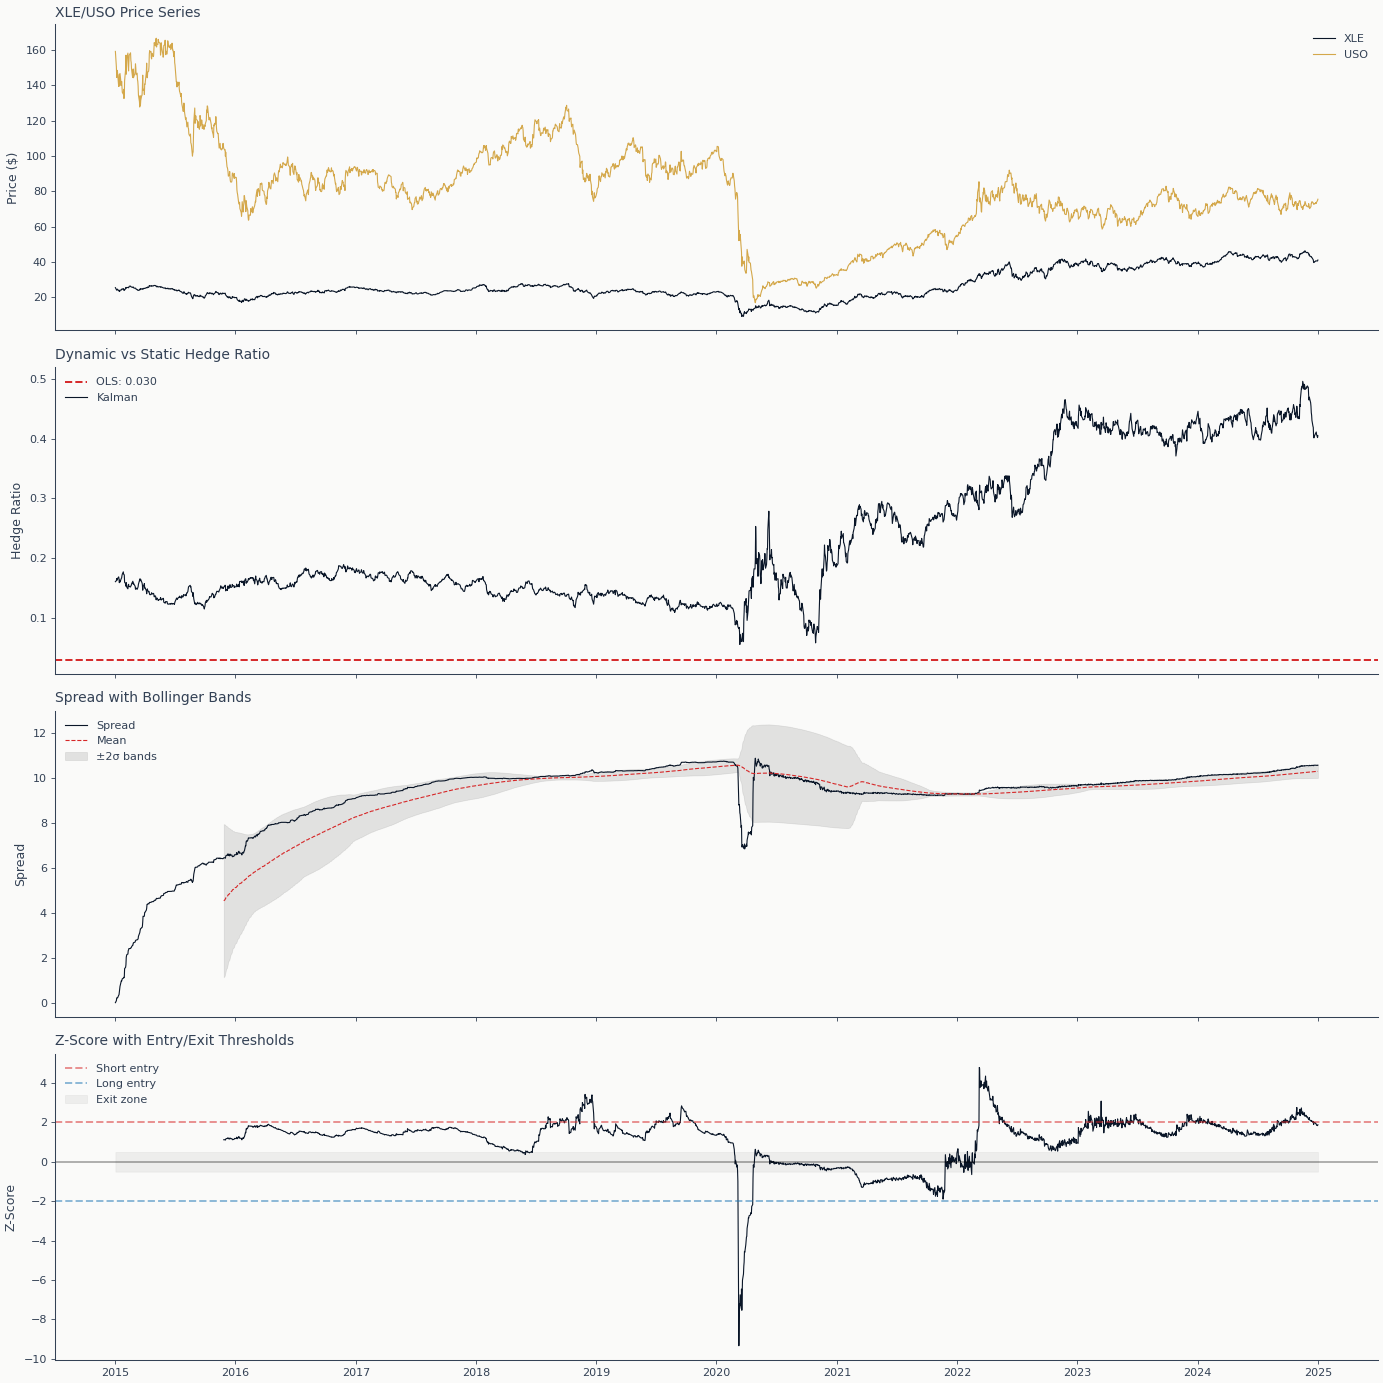

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Price series
ax = axes[0]
ax.plot(df.index, df["Y"], label=PAIR_Y, linewidth=0.8)
ax.plot(df.index, df["X"], label=PAIR_X, linewidth=0.8)
ax.set_ylabel("Price ($)")
ax.set_title(f"{PAIR_Y}/{PAIR_X} Price Series")
ax.legend()

# Hedge ratio evolution
ax = axes[1]
ax.axhline(hedge_ratio_ols, color="#d62728", linestyle="--", label=f"OLS: {hedge_ratio_ols:.3f}")
ax.plot(df.index, df["hedge_ratio_kf"], label="Kalman", linewidth=0.8)
ax.set_ylabel("Hedge Ratio")
ax.set_title("Dynamic vs Static Hedge Ratio")
ax.legend()

# Spread with Bollinger bands
ax = axes[2]
ax.plot(df.index, df["spread_kf"], label="Spread", linewidth=0.8)
ax.plot(df.index, df["spread_mean"], color="#d62728", linestyle="--", linewidth=0.8, label="Mean")
ax.fill_between(
    df.index, df["lower_band"], df["upper_band"], alpha=0.2, color="gray", label="±2σ bands"
)
ax.set_ylabel("Spread")
ax.set_title("Spread with Bollinger Bands")
ax.legend()

# Z-score with entry/exit zones
ax = axes[3]
ax.plot(df.index, df["z_score"], linewidth=0.8)
ax.axhline(2, color="#d62728", linestyle="--", alpha=0.5, label="Short entry")
ax.axhline(-2, color="#1f77b4", linestyle="--", alpha=0.5, label="Long entry")
ax.axhline(0, color="black", linestyle="-", alpha=0.3)
ax.fill_between(df.index, -0.5, 0.5, alpha=0.1, color="gray", label="Exit zone")
ax.set_ylabel("Z-Score")
ax.set_title("Z-Score with Entry/Exit Thresholds")
ax.legend()

plt.tight_layout()
plt.show()

## Illustrative Backtest

A compact backtest demonstrates how cointegration features translate into
tradable signals. This ignores transaction costs and slippage — see
Chapters 18–19 for proper strategy evaluation with realistic cost models.

In [13]:
# Spread returns (long Y, short X when position = 1)
df["ret_y"] = df["Y"].pct_change()
df["ret_x"] = df["X"].pct_change()
df["spread_ret"] = df["position"].shift(1) * (df["ret_y"] - df["ret_x"])
df["spread_ret"] = df["spread_ret"].fillna(0)
df["cumulative_ret"] = (1 + df["spread_ret"]).cumprod() - 1

total_return = df["cumulative_ret"].iloc[-1]
ann_return = (1 + total_return) ** (252 / len(df)) - 1
volatility = df["spread_ret"].std() * np.sqrt(252)
sharpe = ann_return / volatility if volatility > 0 else 0
rolling_max = (1 + df["cumulative_ret"]).cummax()
max_dd = ((1 + df["cumulative_ret"]) / rolling_max - 1).min()

backtest_summary = pd.DataFrame(
    {
        "Total Return": [f"{total_return:.1%}"],
        "Ann. Return": [f"{ann_return:.1%}"],
        "Ann. Vol": [f"{volatility:.1%}"],
        "Sharpe": [f"{sharpe:.2f}"],
        "Max DD": [f"{max_dd:.1%}"],
    }
)
display(backtest_summary)

,Total Return,Ann. Return,Ann. Vol,Sharpe,Max DD
0,111.8%,7.8%,23.3%,0.34,-41.9%


## Summary: Primary Pair Analysis

In [14]:
summary_df = pd.DataFrame(
    {
        "Metric": [
            "Observations",
            "EG p-value",
            "Johansen sig.",
            "OLS hedge ratio",
            "Kalman hedge ratio (final)",
            "Half-life (days)",
        ],
        "Value": [
            f"{len(df):,}",
            f"{eg_pval:.4f}",
            str(johansen_sig),
            f"{hedge_ratio_ols:.4f}",
            f"{hedge_ratios_kf[-1]:.4f}",
            f"{half_life_kf:.1f}",
        ],
    }
)
display(summary_df)

,Metric,Value
0,Observations,"2,516"
1,EG p-value,0.9479
2,Johansen sig.,False
3,OLS hedge ratio,0.0302
4,Kalman hedge ratio (final),0.4049
5,Half-life (days),114.8


## Cointegration Screening: Multiple ETF Pairs

In practice, we screen multiple pairs to find cointegrated relationships.
Not all pairs that seem related are actually cointegrated.

In [15]:
# Screen multiple ETF pairs for cointegration
CANDIDATE_PAIRS = [
    ("GLD", "SLV", "Gold vs Silver"),
    ("XLE", "USO", "Energy vs Crude Oil"),
    ("QQQ", "SMH", "Nasdaq 100 vs Semis"),
    ("SPY", "VTI", "S&P 500 vs Total Mkt"),
    ("TLT", "IEF", "Long vs Mid Treasuries"),
    ("EEM", "VWO", "EM (iShares vs Vanguard)"),
]

screening_results = []

In [16]:
for pair_y, pair_x, description in CANDIDATE_PAIRS:
    y_data = (
        etf_data.filter(pl.col("symbol") == pair_y).select(["timestamp", "close"]).sort("timestamp")
    )
    x_data = (
        etf_data.filter(pl.col("symbol") == pair_x).select(["timestamp", "close"]).sort("timestamp")
    )

    if len(y_data) < 252 or len(x_data) < 252:
        continue

    y_df = y_data.rename({"close": "Y"})
    x_df = x_data.rename({"close": "X"})
    pair_df = y_df.join(x_df, on="timestamp", how="inner").to_pandas().set_index("timestamp")

    if len(pair_df) < 252:
        continue

    # Engle-Granger test
    eg_stat, eg_pval_pair, _ = coint(pair_df["Y"], pair_df["X"], trend="c")[:3]

    # Johansen test
    joh = coint_johansen(pair_df[["Y", "X"]], det_order=0, k_ar_diff=1)
    joh_sig = joh.lr1[0] > joh.cvt[0, 1]

    # Hedge ratio and half-life
    ols_temp = LinearRegression()
    ols_temp.fit(pair_df[["X"]], pair_df["Y"])
    hedge = ols_temp.coef_[0]
    hl = estimate_half_life(pair_df["Y"] - hedge * pair_df["X"])

    screening_results.append(
        {
            "Pair": f"{pair_y}/{pair_x}",
            "Description": description,
            "Obs": len(pair_df),
            "EG p-value": eg_pval_pair,
            "Johansen": "Yes" if joh_sig else "No",
            "Cointegrated": eg_pval_pair < 0.05,
            "Hedge Ratio": hedge,
            "Half-life (d)": hl,
        }
    )

In [17]:
# Display screening results as a formatted table
screening_df = pd.DataFrame(screening_results)
display_df = screening_df[
    ["Pair", "Description", "EG p-value", "Johansen", "Hedge Ratio", "Half-life (d)"]
].copy()
display_df["EG p-value"] = display_df["EG p-value"].map(lambda x: f"{x:.4f}")
display_df["Hedge Ratio"] = display_df["Hedge Ratio"].map(lambda x: f"{x:.3f}")
display_df["Half-life (d)"] = display_df["Half-life (d)"].map(
    lambda x: f"{x:.1f}" if x < 1000 else "N/A"
)
display(display_df)

,Pair,Description,EG p-value,Johansen,Hedge Ratio,Half-life (d)
0,GLD/SLV,Gold vs Silver,0.2708,Yes,7.636,109.7
1,XLE/USO,Energy vs Crude Oil,0.9479,No,0.030,N/A
2,QQQ/SMH,Nasdaq 100 vs Semis,0.4251,No,1.832,154.3
3,SPY/VTI,S&P 500 vs Total Mkt,0.6143,No,2.042,223.0
4,TLT/IEF,Long vs Mid Treasuries,0.9606,No,2.190,270.0
5,EEM/VWO,EM (iShares vs Vanguard),0.9876,No,0.970,N/A


Economic relatedness does not guarantee cointegration — several
apparently related pairs fail the Engle-Granger test, and the two
tests sometimes disagree. Half-lives range from days to months,
reflecting the speed at which different pair relationships mean-revert.
Only pairs with short half-lives (days to weeks) are practical for
trading at daily frequency.

## Save Pairs Trading Features for Downstream Chapters

Spread signals and hedge ratios are consumed by:
- Chapter 18: Strategy simulation (pairs trading backtest)
- Chapter 19: Portfolio construction (market-neutral portfolios)

In [18]:
# Save pairs trading data to output directory for ALL cointegrated pairs
MODEL_DIR = get_case_study_dir("etfs") / "models" / "time_series"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

### Generate Signals for Cointegrated Pairs

Package spread signals and hedge ratios for all cointegrated pairs,
saving for downstream strategy evaluation in Chapters 18–19.

In [19]:
def generate_pair_signals(pair_y: str, pair_x: str) -> pl.DataFrame | None:
    """Generate Kalman-filtered spread signals for a single pair."""
    y_data = (
        etf_data.filter(pl.col("symbol") == pair_y).select(["timestamp", "close"]).sort("timestamp")
    )
    x_data = (
        etf_data.filter(pl.col("symbol") == pair_x).select(["timestamp", "close"]).sort("timestamp")
    )

    if len(y_data) < 252 or len(x_data) < 252:
        return None

    y_df = y_data.rename({"close": "Y"})
    x_df = x_data.rename({"close": "X"})
    pair_df = y_df.join(x_df, on="timestamp", how="inner").to_pandas().set_index("timestamp")
    pair_df.index = pd.DatetimeIndex(pair_df.index)

    if len(pair_df) < 252:
        return None

    # Kalman filter hedge ratio and spread
    kf_hedges, _ = kalman_hedge_ratio(pair_df["Y"].values, pair_df["X"].values)
    pair_df["spread_kf"] = pair_df["Y"] - kf_hedges * pair_df["X"]

    # Z-score from half-life based lookback
    hl = estimate_half_life(pair_df["spread_kf"])
    lb = max(int(2 * hl), 20)
    rm = pair_df["spread_kf"].rolling(window=lb).mean()
    rs = pair_df["spread_kf"].rolling(window=lb).std()
    pair_df["z_score"] = (pair_df["spread_kf"] - rm) / rs

    pair_df["signal"] = 0
    pair_df.loc[pair_df["z_score"] < -2, "signal"] = 1
    pair_df.loc[pair_df["z_score"] > 2, "signal"] = -1

    return pl.DataFrame(
        {
            "timestamp": pair_df.index.values,
            "pair": f"{pair_y}/{pair_x}",
            "asset_y": pair_y,
            "asset_x": pair_x,
            "hedge_ratio": kf_hedges,
            "spread": pair_df["spread_kf"].values,
            "z_score": pair_df["z_score"].values,
            "signal": pair_df["signal"].values,
        }
    ).drop_nulls()

In [20]:
# Apply to all cointegrated pairs
all_signals = []
cointegrated_pairs = [r for r in screening_results if r["Cointegrated"]]

print(f"Processing {len(cointegrated_pairs)} cointegrated pairs...")

for r in cointegrated_pairs:
    pair_y, pair_x = r["Pair"].split("/")
    signals = generate_pair_signals(pair_y, pair_x)
    if signals is not None:
        all_signals.append(signals)

# Also include the primary pair if not already included
if f"{PAIR_Y}/{PAIR_X}" not in [r["Pair"] for r in cointegrated_pairs]:
    primary_signals = pl.DataFrame(
        {
            "timestamp": df.index.values,
            "pair": f"{PAIR_Y}/{PAIR_X}",
            "asset_y": PAIR_Y,
            "asset_x": PAIR_X,
            "hedge_ratio": df["hedge_ratio_kf"].values,
            "spread": df["spread_kf"].values,
            "z_score": df["z_score"].values,
            "signal": df["signal"].values,
        }
    ).drop_nulls()
    all_signals.append(primary_signals)
    print(f"  {PAIR_Y}/{PAIR_X}: {len(primary_signals)} obs (primary)")

Processing 0 cointegrated pairs...
  XLE/USO: 2516 obs (primary)


In [21]:
# Combine and save
if all_signals:
    combined_signals = pl.concat(all_signals)
    output_path = MODEL_DIR / "pairs_trading_signals.parquet"
    combined_signals.write_parquet(output_path)

    print(f"\n[OK] Saved pairs trading signals to {output_path}")
    print(f"  Shape: {combined_signals.shape}")
    print(f"  Pairs: {combined_signals['pair'].unique().to_list()}")
    print(
        f"  Date range: {combined_signals['timestamp'].min()} to {combined_signals['timestamp'].max()}"
    )

    # Per-pair summary
    print("\n  Per-pair summary:")
    summary = combined_signals.group_by("pair").agg(pl.len().alias("n_rows")).sort("pair")
    for row in summary.iter_rows(named=True):
        print(f"    {row['pair']}: {row['n_rows']:,} rows")
else:
    print("\nWARNING: No pairs trading signals generated")


[OK] Saved pairs trading signals to case_studies/etfs/models/time_series/pairs_trading_signals.parquet
  Shape: (2516, 8)
  Pairs: ['XLE/USO']
  Date range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00

  Per-pair summary:
    XLE/USO: 2,516 rows


## ml4t-engineer: Cross-Asset Features as Polars Expressions

The manual pairwise analysis above uses statsmodels and numpy for each pair.
`ml4t-engineer` provides cross-asset features as Polars expressions for
multi-pair pipelines: rolling correlation, beta, dispersion, and
cointegration scoring.

In [22]:
# Demonstrate cross-asset features on a pair
gld = etf_data.filter(pl.col("symbol") == "GLD").select(["timestamp", "close"]).sort("timestamp")
slv = etf_data.filter(pl.col("symbol") == "SLV").select(["timestamp", "close"]).sort("timestamp")

pair_df = (
    gld.rename({"close": "gld_close"})
    .join(slv.rename({"close": "slv_close"}), on="timestamp", how="inner")
    .with_columns(
        gld_ret=pl.col("gld_close").pct_change(),
        slv_ret=pl.col("slv_close").pct_change(),
    )
    .drop_nulls()
)

# Cross-asset features in one pipeline
pair_features = pair_df.with_columns(
    corr=rolling_correlation("gld_ret", "slv_ret", window=60),
    beta=beta_to_market("slv_ret", "gld_ret", window=60),
    coint_score=co_integration_score("gld_close", "slv_close", window=120),
)

# Correlation regime indicators (returns dict)
corr_regime = correlation_regime_indicator("corr")
pair_features = pair_features.with_columns(**corr_regime)

print("=== ml4t-engineer: Cross-Asset Features (GLD/SLV) ===")
for col in ["corr", "beta", "coint_score"]:
    vals = pair_features[col].drop_nulls()
    _m, _s = vals.mean(), vals.std()
    print(
        f"  {col:<14}: mean={_m:.4f}, std={_s:.4f}"
        if _m is not None
        else f"  {col:<14}: insufficient data"
    )

=== ml4t-engineer: Cross-Asset Features (GLD/SLV) ===
  corr          : mean=0.7799, std=0.0622
  beta          : mean=1.4323, std=0.3169
  coint_score   : mean=0.0697, std=0.0570


The library expressions compose naturally in `with_columns()`, making it
straightforward to compute cross-asset features across many pairs in a
single Polars pipeline. `correlation_regime_indicator()` adds binary
regime flags based on rolling correlation levels — useful for
conditional feature engineering.

## Cross-Sectional Ranking of Temporal Features

Raw temporal features (momentum, conditional volatility, regime
probabilities) vary in scale across assets. Cross-sectional ranking
converts them to universe-relative signals — essential for panel models
that predict cross-sectional returns.

In [23]:
# Compute temporal features for a multi-asset ETF universe
RANK_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "XLE", "XLF", "XLV"]
rank_symbols = [s for s in RANK_SYMBOLS if s in available_symbols]

panel = (
    etf_data.filter(pl.col("symbol").is_in(rank_symbols))
    .select(["timestamp", "symbol", "close"])
    .sort(["symbol", "timestamp"])
)

# Temporal features: momentum (60d return) and volatility (60d rolling std of returns)
panel = (
    panel.with_columns(
        ret=pl.col("close").pct_change().over("symbol"),
    )
    .with_columns(
        momentum_60d=pl.col("ret").rolling_mean(60).over("symbol"),
        vol_60d=pl.col("ret").rolling_std(60).over("symbol"),
    )
    .drop_nulls()
)

print(f"Panel: {panel['symbol'].n_unique()} assets, {len(panel):,} obs")

Panel: 10 assets, 24,560 obs


In [24]:
# Cross-sectional rank, percentile, and z-score at each date
panel = panel.with_columns(
    rank_momentum=pl.col("momentum_60d").rank().over("timestamp"),
    rank_vol=pl.col("vol_60d").rank().over("timestamp"),
    pct_momentum=(pl.col("momentum_60d").rank().over("timestamp") - 1)
    / (pl.col("momentum_60d").count().over("timestamp") - 1),
    zscore_momentum=(
        (pl.col("momentum_60d") - pl.col("momentum_60d").mean().over("timestamp"))
        / pl.col("momentum_60d").std().over("timestamp")
    ),
)

# Show a snapshot for one date
snapshot_date = panel["timestamp"].unique().sort().to_list()[-252]  # ~1 year ago
snapshot = (
    panel.filter(pl.col("timestamp") == snapshot_date)
    .select(["symbol", "momentum_60d", "rank_momentum", "pct_momentum", "zscore_momentum"])
    .sort("rank_momentum")
)
print(f"\nCross-sectional snapshot ({snapshot_date}):")
display(snapshot.to_pandas())


Cross-sectional snapshot (2024-01-02):


,symbol,momentum_60d,rank_momentum,pct_momentum,zscore_momentum
0,XLE,0.000142,1.0,0.000000,-2.281951
1,XLV,0.001367,2.0,0.111111,-0.640358
2,EEM,0.001419,3.0,0.222222,-0.570714
3,EFA,0.001823,4.0,0.333333,-0.029018
4,SPY,0.001888,5.0,0.444444,0.058368
5,QQQ,0.002016,6.0,0.555556,0.230202
6,GLD,0.002074,7.0,0.666667,0.307771
7,XLF,0.002488,8.0,0.777778,0.863168
8,TLT,0.002518,9.0,0.888889,0.903044
9,IWM,0.002710,10.0,1.000000,1.159488


/tmp/ipykernel_1852198/770753372.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


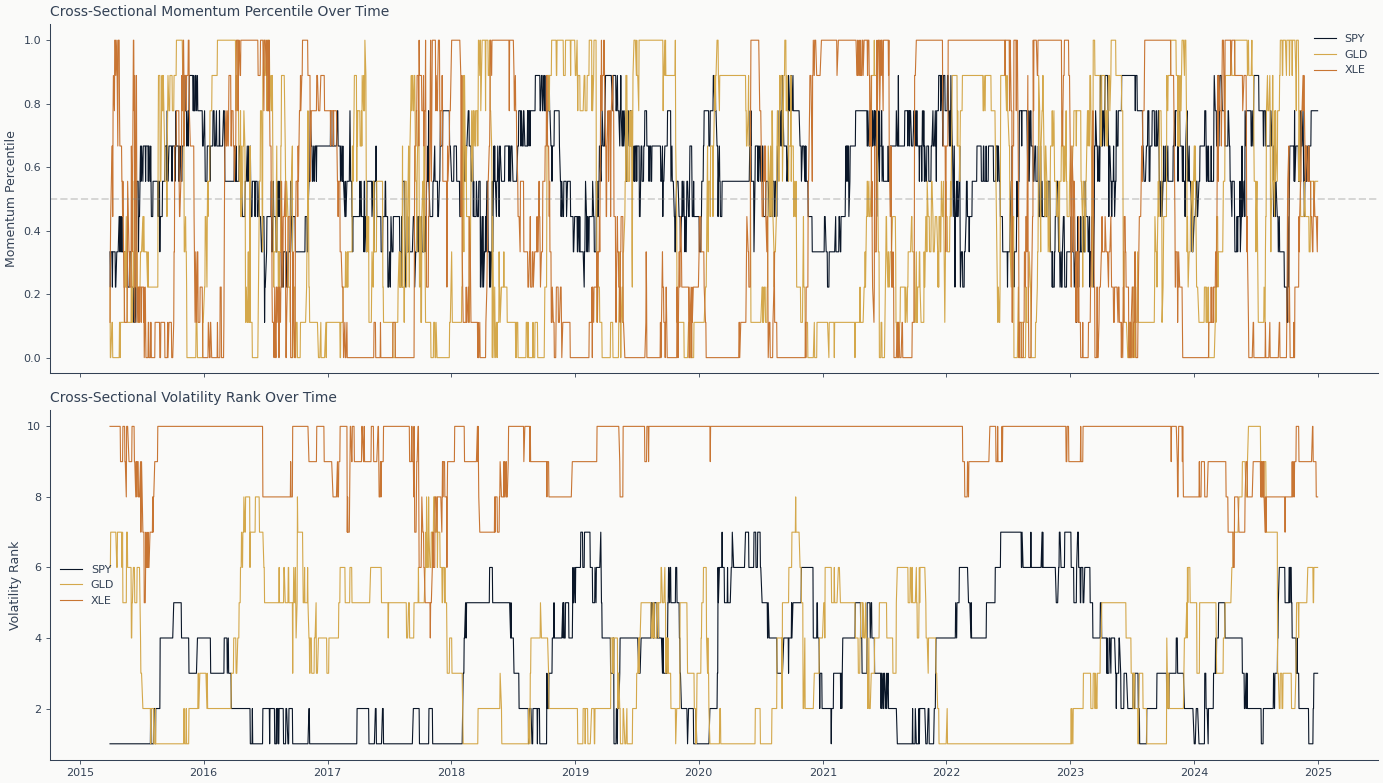

In [25]:
# Visualize rank evolution over time for selected assets
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

highlight = ["SPY", "GLD", "XLE"]
for sym in highlight:
    sym_data = panel.filter(pl.col("symbol") == sym).to_pandas()
    axes[0].plot(sym_data["timestamp"], sym_data["pct_momentum"], label=sym, linewidth=0.8)
    axes[1].plot(sym_data["timestamp"], sym_data["rank_vol"], label=sym, linewidth=0.8)

axes[0].set_ylabel("Momentum Percentile")
axes[0].set_title("Cross-Sectional Momentum Percentile Over Time")
axes[0].legend()
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.3)

axes[1].set_ylabel("Volatility Rank")
axes[1].set_title("Cross-Sectional Volatility Rank Over Time")
axes[1].legend()

plt.tight_layout()
plt.show()

Ranks are bounded, stationary, and immune to outliers. A high
momentum rank (top of universe) followed by rank decay signals
momentum exhaustion — a feature that absolute momentum values
cannot express because their scale drifts with market conditions.

## Relative Temporal Features

Many temporal features gain signal when expressed relative to a
benchmark — isolating idiosyncratic dynamics from systematic exposure.
We demonstrate market-relative features (vs SPY). Sector-relative
features follow the same pattern with a sector ETF as benchmark
(e.g., XLE momentum minus XLF momentum isolates energy-specific signal).

/tmp/ipykernel_1852198/2331146836.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


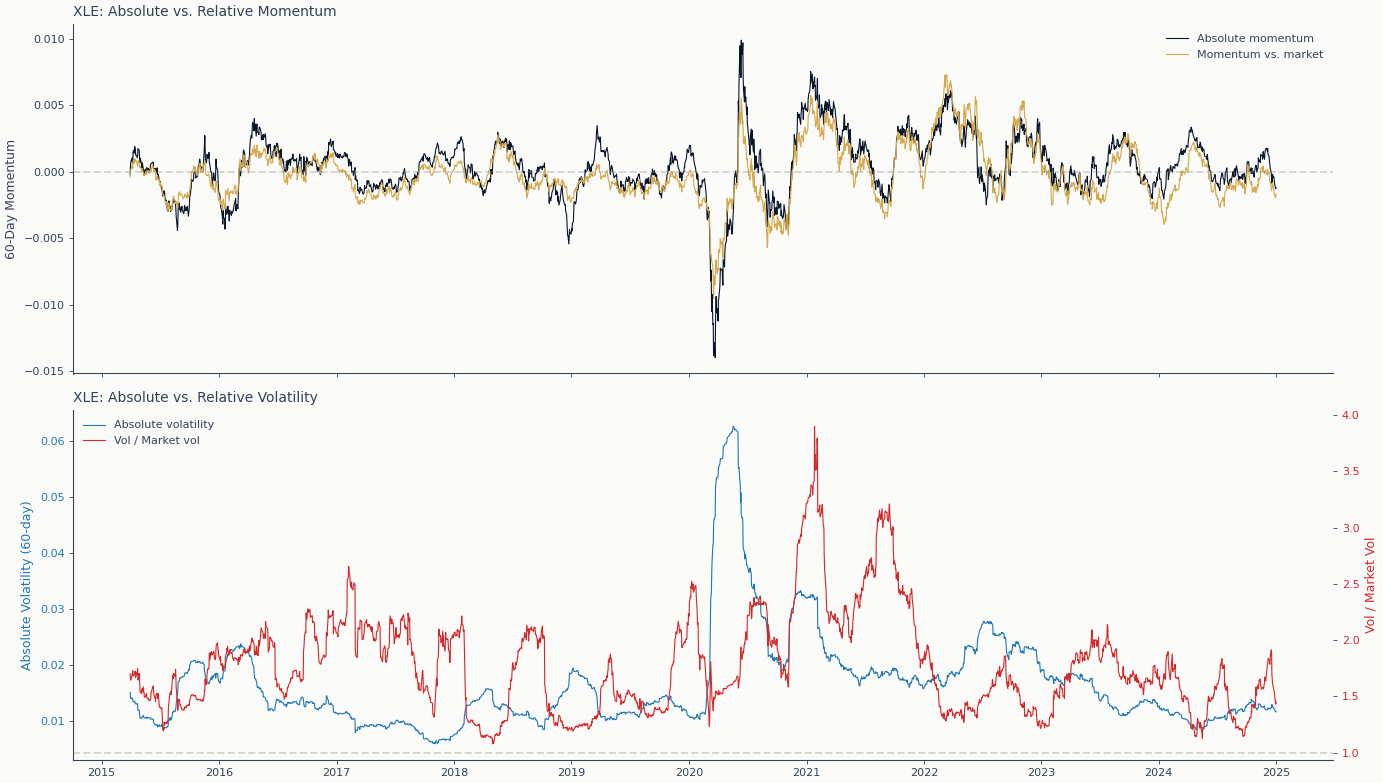

In [26]:
# Compute relative features: asset vs. market (SPY as proxy)
spy_features = (
    panel.filter(pl.col("symbol") == "SPY")
    .select(["timestamp", "momentum_60d", "vol_60d"])
    .rename({"momentum_60d": "mkt_momentum", "vol_60d": "mkt_vol"})
)

panel_rel = panel.join(spy_features, on="timestamp", how="inner")

panel_rel = panel_rel.with_columns(
    momentum_vs_market=pl.col("momentum_60d") - pl.col("mkt_momentum"),
    vol_vs_market=pl.col("vol_60d") / pl.col("mkt_vol"),
)

# Compare absolute vs relative for one asset
xle = panel_rel.filter(pl.col("symbol") == "XLE").to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(xle["timestamp"], xle["momentum_60d"], label="Absolute momentum", linewidth=0.8)
axes[0].plot(
    xle["timestamp"], xle["momentum_vs_market"], label="Momentum vs. market", linewidth=0.8
)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.3)
axes[0].set_ylabel("60-Day Momentum")
axes[0].set_title("XLE: Absolute vs. Relative Momentum")
axes[0].legend()

# Absolute vol (~0.005 daily) and the vol-ratio (~1-3.5) live on different scales,
# so use twin y-axes to keep both visible.
ax_abs = axes[1]
ax_rel = ax_abs.twinx()
(l_abs,) = ax_abs.plot(
    xle["timestamp"], xle["vol_60d"], label="Absolute volatility", linewidth=0.8, color="#1f77b4"
)
(l_rel,) = ax_rel.plot(
    xle["timestamp"],
    xle["vol_vs_market"],
    label="Vol / Market vol",
    linewidth=0.8,
    color="#d62728",
)
ax_rel.axhline(1.0, color="gray", linestyle="--", alpha=0.3)
ax_abs.set_ylabel("Absolute Volatility (60-day)", color="#1f77b4")
ax_rel.set_ylabel("Vol / Market Vol", color="#d62728")
ax_abs.tick_params(axis="y", labelcolor="#1f77b4")
ax_rel.tick_params(axis="y", labelcolor="#d62728")
ax_abs.set_title("XLE: Absolute vs. Relative Volatility")
ax_abs.legend(handles=[l_abs, l_rel], loc="upper left")

plt.tight_layout()
plt.show()

Relative momentum removes the market component — XLE's energy-sector
bets become visible only after subtracting the broad equity trend.
Relative volatility (vol / market vol) distinguishes periods where an
asset is genuinely more volatile from periods where the entire market
is stressed. Values above 1.0 indicate the asset carries more risk
than the market; values below 1.0 indicate relative calm.

## Multi-Asset Regime Aggregation (Illustrative)

Individual regime classifications (from `11_hmm_regimes`) gain
power when aggregated across the universe. We approximate per-asset
regime probabilities from realized volatility percentiles to
demonstrate the aggregation mechanics. This is exploratory — the
full-history ranking introduces look-ahead. In production, use
HMM-filtered regime probabilities estimated within walk-forward folds.

In [27]:
# Illustrative regime probabilities from rolling volatility (proxy for HMM crisis probs).
# WARNING: This ranks each asset's volatility over its FULL history — a look-ahead
# shortcut for demonstrating the aggregation mechanics. In production, use per-asset
# HMM filtered probabilities estimated inside walk-forward folds (see 11_hmm_regimes).
vol_panel = panel.select(["timestamp", "symbol", "vol_60d"]).with_columns(
    crisis_prob=(
        pl.col("vol_60d").rank().over(["symbol"]) / pl.col("vol_60d").count().over(["symbol"])
    ),
)

# Universe-level aggregations at each timestamp
regime_agg = (
    vol_panel.group_by("timestamp")
    .agg(
        universe_crisis_prob=pl.col("crisis_prob").mean(),
        crisis_breadth=(pl.col("crisis_prob") > 0.7).mean(),  # fraction above 70th pct
        regime_dispersion=pl.col("crisis_prob").std(),
    )
    .sort("timestamp")
)

# Plot against SPY returns
spy_ret = (
    etf_data.filter(pl.col("symbol") == "SPY")
    .select(["timestamp", "close"])
    .sort("timestamp")
    .with_columns(spy_cumret=(pl.col("close") / pl.col("close").first() - 1) * 100)
)

agg_pd = regime_agg.join(
    spy_ret.select(["timestamp", "spy_cumret"]), on="timestamp", how="inner"
).to_pandas()

/tmp/ipykernel_1852198/1686085363.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


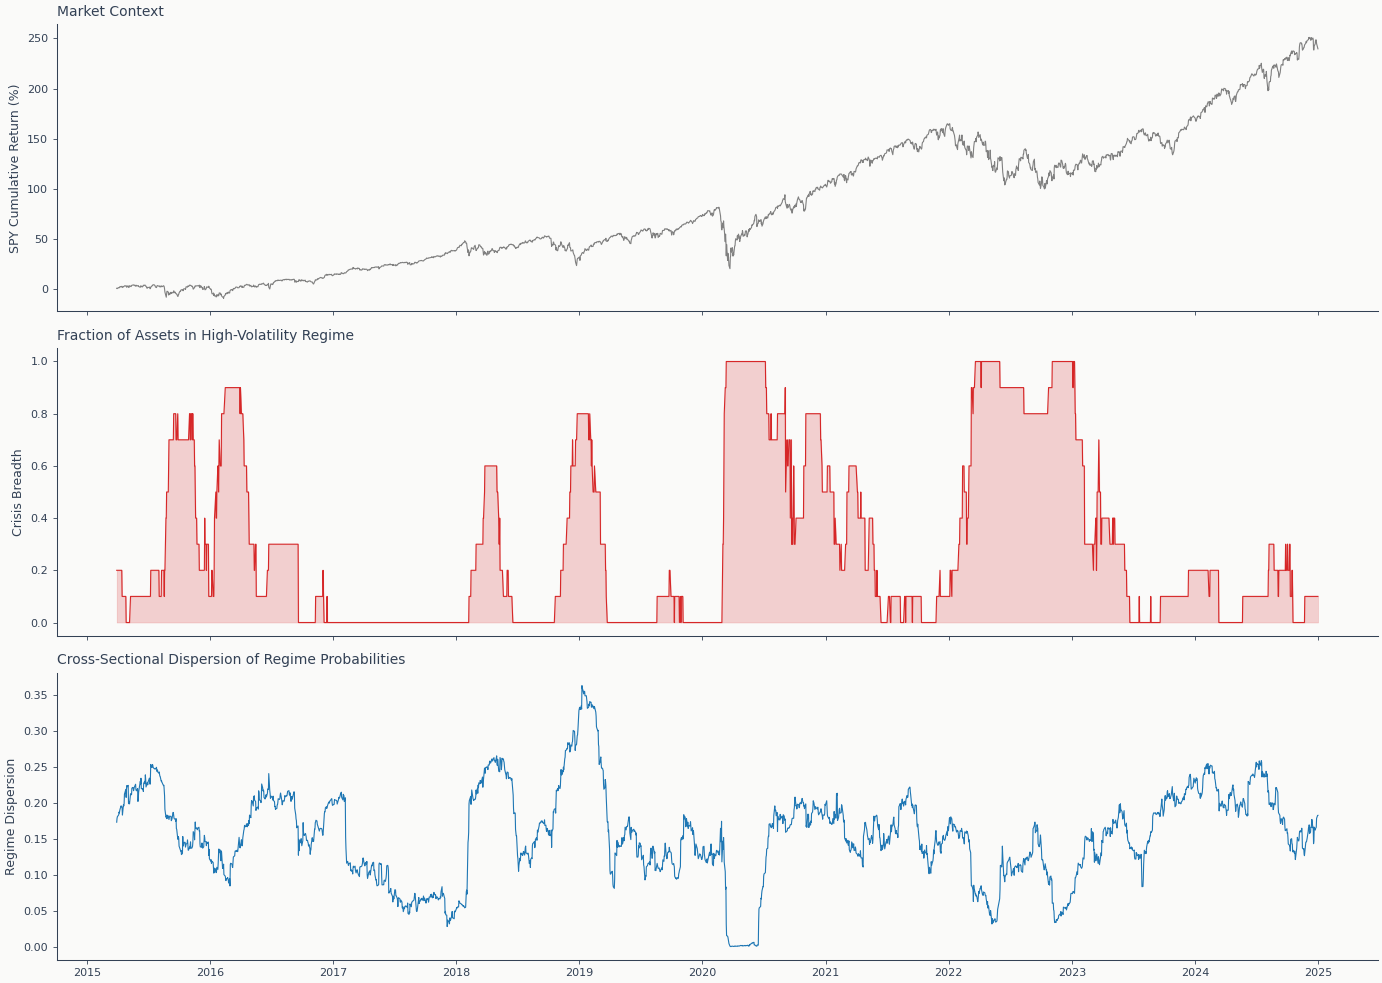

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(agg_pd["timestamp"], agg_pd["spy_cumret"], linewidth=0.8, color="gray")
axes[0].set_ylabel("SPY Cumulative Return (%)")
axes[0].set_title("Market Context")

axes[1].plot(agg_pd["timestamp"], agg_pd["crisis_breadth"], linewidth=0.8, color="#d62728")
axes[1].fill_between(agg_pd["timestamp"], 0, agg_pd["crisis_breadth"], alpha=0.2, color="#d62728")
axes[1].set_ylabel("Crisis Breadth")
axes[1].set_title("Fraction of Assets in High-Volatility Regime")

axes[2].plot(agg_pd["timestamp"], agg_pd["regime_dispersion"], linewidth=0.8, color="#1f77b4")
axes[2].set_ylabel("Regime Dispersion")
axes[2].set_title("Cross-Sectional Dispersion of Regime Probabilities")

plt.tight_layout()
plt.show()

Crisis breadth spikes during market selloffs (visible as SPY drawdowns),
confirming that aggregating individual regime indicators produces
a useful system-wide stress signal. Regime dispersion is low during
broad crises (all assets move together) and high during sector
rotations (differentiated behavior) — making it a complement to
crisis breadth rather than a substitute.

## Key Takeaways

1. **Cross-sectional ranking normalizes temporal features** — ranks are
   scale-invariant, outlier-robust, and stationary, making heterogeneous
   assets comparable for panel models
2. **Relative features decompose alpha from beta** — asset momentum minus
   sector momentum isolates idiosyncratic signal from systematic exposure
3. **Two cointegration tests for robustness** — Engle-Granger and Johansen
   may disagree; treat pairs with caution when they do
4. **Kalman filter adapts** — dynamic hedge ratios track structural shifts
   that a static OLS estimate misses
5. **Half-life guides lookback** — use 2x half-life for rolling z-score
   windows; short half-lives are more practical for trading
6. **Screen multiple pairs** — economic relatedness does not guarantee
   cointegration; the `ml4t-engineer` library scales this analysis
   with Polars-native expressions

**Previous**: `13_regime_as_feature` for regime features in ML pipelines.
**Book**: Chapter 9, Section 9.6 discusses cross-sectional ranking,
relative features, and panel aggregation in depth.